# Sleep Stage Classification using EEG Data

Data Format: EDF

Channel type:

- Electroencephalography (EEG)
- Electrooculography (EOG)
- Respiration
- Electromyography (EMG)
- Temperature

Label category:

- Wake (W)
- Sleep Stage 1
- Sleep Stage 2
- Sleep Stage 3/4
- Sleep REM (R)

Used a 'leave-one-participant-out' cross-validation scheme.

In [1]:
!pip install mne


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import LeaveOneGroupOut

import mne
from mne.datasets.sleep_physionet.age import fetch_data

# Analysis for 10 participants with 3 sleep stage classification

In [3]:
# experiment variables

# classification label target
EVENT_ID = {
    "Sleep stage W": 1,         # WakeUp
    "Sleep stage 1/2/3/4": 2,   # Sleep Stages 1/2/3/4
    "Sleep stage R": 3,         # Rapid-Eye-Movement
}

# Frequency bands range (in Hz) for EEG
FREQ_BANDS = {
    "delta": [0.5, 4.5],
    "theta": [4.5, 8.5],
    "alpha": [8.5, 11.5],
    "sigma": [11.5, 15.5],
    "beta": [15.5, 30],
}

# Number of participants used in the analysis
NUM_PARTICIPANT = 10

In [4]:
def load_data(participant_id, event_id=EVENT_ID):
    
  """ 
  Will load the EDF with annotation for a given participant and create
  30 seconds epochs.

  Parameters -->
  participant_id:
    The subjects/person to use. Can be in the range of 0-82 (inclusive), but the
    following subjects are not available: 39, 68, 69, 78 and 79.

  Return --> 
  raw_edf: Contains the edf with the annotations
  events: Contains the 30 seconds events
  epochs: the 30 seconds epoch

  Limitation -->
    Will only get 1 recording session
    Will only work for 1 subject at a time
    
  """

  ANNOTATION_EVENT_ID = {
    "Sleep stage W": 1,
      
    "Sleep stage 1": 2,
    "Sleep stage 2": 2,
    "Sleep stage 3": 2,
    "Sleep stage 4": 2,
      
    "Sleep stage R": 3,
  }

  # Load two file paths, one for the signal and one for the annotations
  # [participant_file] -> [participant_file][0] for signal and [participant_file][1] for annotations.
  [participant_file] = fetch_data(subjects=[participant_id], recording=[1]) # recordings of first night session taken.

  # reads the digital signal file into memory.
  raw_edf = mne.io.read_raw_edf(
    participant_file[0], # signal
    stim_channel="Event marker",
    infer_types=True,
    preload=True,
    verbose="error"
  )

  # Read the annotation file
  annotation_edf = mne.read_annotations(participant_file[1])

  # keep last 2h wake events before sleep and first 2h wake events after sleep [30*240 = 7200 sec = 2 hours]
  # and redefine annotations on raw data
  annotation_edf.crop(annotation_edf[1]["onset"] - 30 * 240, annotation_edf[-2]["onset"] + 30 * 240)

  # Attach the annotation file to the raw edf loaded
  raw_edf.set_annotations(annotation_edf, emit_warning=False)

  # Chunk the data into 30 seconds epochs
  events, _ = mne.events_from_annotations(
      raw_edf, event_id=ANNOTATION_EVENT_ID, chunk_duration=30.0
  )
    
  # to ensure the segments don't overlap.
  tmax = 30.0 - 1.0 / raw_edf.info["sfreq"]

  # Create the epochs for classification
  epochs = mne.Epochs(
      raw=raw_edf,
      events=events,
      event_id=event_id,
      tmin=0.0,
      tmax=tmax,
      baseline=None,
      preload=True,
  )

  return raw_edf, events, epochs

In [5]:
# Load NUM_PARTICIPANT data and storingr them for further processing
all_participant_epochs = []
for participant_id in range(NUM_PARTICIPANT): # runs 10 times
  # calling 'load_data' funtion for each participant and fetching the epochs
  _, _, epochs = load_data(participant_id=participant_id)
  all_participant_epochs.append(epochs)

Using default location ~/mne_data for PHYSIONET_SLEEP...
Used Annotations descriptions: ['Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R', 'Sleep stage W']
Not setting metadata
1201 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1201 events and 3000 original time points ...
0 bad epochs dropped
Using default location ~/mne_data for PHYSIONET_SLEEP...
Used Annotations descriptions: ['Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R', 'Sleep stage W']
Not setting metadata
1463 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1463 events and 3000 original time points ...
0 bad epochs dropped
Using default location ~/mne_data for PHYSIONET_SLEEP...
Used Annotations descriptions: ['Sleep stage 1', 'Sleep stage 2', 'Sleep stage 3', 'Sleep stage 4', 'Sleep stage R', 'Sleep stage W']
Not setti

In [6]:
all_participant_epochs
# Will be getting epoch statistics for the three sleep stages for each of 10 participants.

[<Epochs | 1201 events (all good), 0 – 29.99 s (baseline off), ~192.4 MiB, data loaded,
  'Sleep stage W': 548
  'Sleep stage 1/2/3/4': 528
  'Sleep stage R': 125>,
 <Epochs | 1463 events (all good), 0 – 29.99 s (baseline off), ~234.4 MiB, data loaded,
  'Sleep stage W': 517
  'Sleep stage 1/2/3/4': 776
  'Sleep stage R': 170>,
 <Epochs | 1385 events (all good), 0 – 29.99 s (baseline off), ~221.9 MiB, data loaded,
  'Sleep stage W': 488
  'Sleep stage 1/2/3/4': 734
  'Sleep stage R': 163>,
 <Epochs | 1312 events (all good), 0 – 29.99 s (baseline off), ~210.2 MiB, data loaded,
  'Sleep stage W': 500
  'Sleep stage 1/2/3/4': 603
  'Sleep stage R': 209>,
 <Epochs | 1595 events (all good), 0 – 29.99 s (baseline off), ~255.6 MiB, data loaded,
  'Sleep stage W': 560
  'Sleep stage 1/2/3/4': 839
  'Sleep stage R': 196>,
 <Epochs | 1032 events (all good), 0 – 29.99 s (baseline off), ~165.4 MiB, data loaded,
  'Sleep stage W': 568
  'Sleep stage 1/2/3/4': 396
  'Sleep stage R': 68>,
 <Epochs | 

In [7]:
def eeg_power_band(epochs, freq_bands=FREQ_BANDS):
  # Calculate relative spectral analysis on the EEG sensors for each epochs
    
  # Calculate the spectrogram
  # Power Spectral Density (PSD) calculation, uses fourier-transform to change time-domain to frequency domain signal.
  spectrum = epochs.compute_psd(picks="eeg", fmin=0.5, fmax=30.0) # picking only 'eeg', discarding 'eog','emg' and others.
  psds, freqs = spectrum.get_data(return_freqs=True) # power_value, list of freq. matching that power_value

  # Normalization
  psds /= np.sum(psds, axis=-1, keepdims=True)

  # shape of PSDS:
  # Till now, we have 3D stack of epochs, each containing two channels,
  # and each channels have hundeds of tiny bins.. e.g., 0.5Hz, 0.6Hz, 0.7Hz...
  # (epoch, number of channels (we have 2), frequency_bins)
  # We'll slice and average to get the delta to theta bands (5 feature per channel)
  # Therefore we should finish with (epoch, number of channels * number of bands)
  # 2 Channels * 5 Bands = 10 Features/epochs

  X = []
  # For each frequency band (delta, theta..) get the mean value and add it to the list X
  for fmin, fmax in freq_bands.values():
    psds_band = psds[:, :, (freqs >= fmin) & (freqs < fmax)].mean(axis=-1)  
    # all epochs, both channels, but mean of power values for the frequencies between fmin and fmax.
    X.append(psds_band.reshape(len(psds), -1))

  # 2 EEG channels and 5 frequency bands, getting 10 features for every 30-second epoch.
  # Total 10 values in X, in one 'eeg_power_band' call.
  return np.concatenate(X, axis=1)

In [8]:
# Iterate over the 30 seconds epochs, calculate the powerband features
# Then define the right id for the "group" which should be the participant_id

X = []
y = []
groups = []
for group_id, epochs in enumerate(all_participant_epochs): # take indivisual epoch of each participant
  print(f"Processing participants #{group_id}")

  X_epoch = eeg_power_band(epochs) # calculate 'eeg_power_band' for each (10 features)
  y_epoch = epochs.events[:, 2] # fetch the true label
  group_epoch = [group_id]*len(y_epoch) # creating another column of 'group' of that epoch.

  X.append(X_epoch)
  y.append(y_epoch)
  groups.append(group_epoch)

# Transform these lists into numpy array with proper size for sklearn models
X = np.concatenate(X, axis=0)
y = np.concatenate(y, axis=0)
groups = np.concatenate(groups, axis=0)

Processing participants #0
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #1
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #2
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #3
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #4
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #5
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #6
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #7
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #8
    Using multitaper spectrum estimation with 7 DPSS windows
Processing participants #9
    Using multitaper spectrum estimation with 7 DPSS windows


Testing on participant: #0
Accuracy score: 0.8792672772689425
                     precision    recall  f1-score   support

      Sleep stage W       1.00      0.86      0.92       548
Sleep stage 1/2/3/4       0.86      0.92      0.89       528
      Sleep stage R       0.60      0.78      0.67       125

           accuracy                           0.88      1201
          macro avg       0.82      0.85      0.83      1201
       weighted avg       0.90      0.88      0.88      1201

{'Sleep stage W': 1, 'Sleep stage 1/2/3/4': 2, 'Sleep stage R': 3}
Testing on participant: #1
Accuracy score: 0.885850991114149
                     precision    recall  f1-score   support

      Sleep stage W       0.85      0.99      0.92       517
Sleep stage 1/2/3/4       0.96      0.83      0.89       776
      Sleep stage R       0.74      0.82      0.78       170

           accuracy                           0.89      1463
          macro avg       0.85      0.88      0.86      1463
       weigh

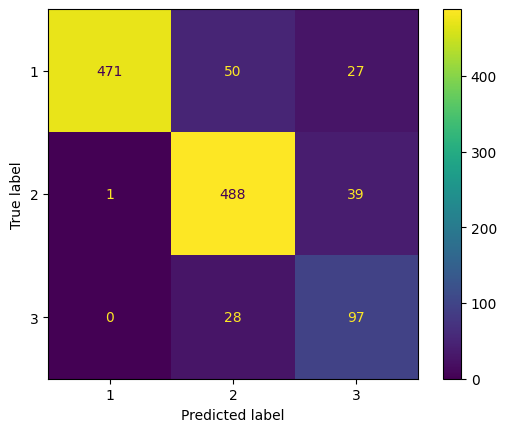

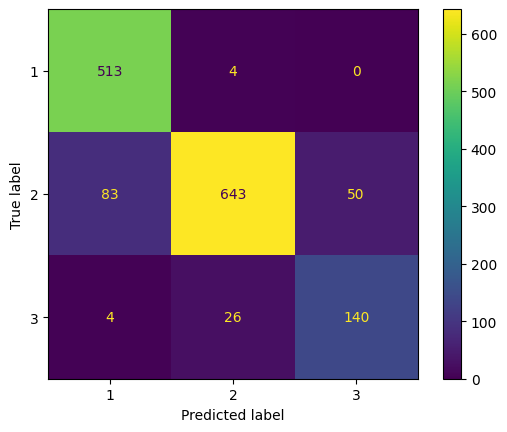

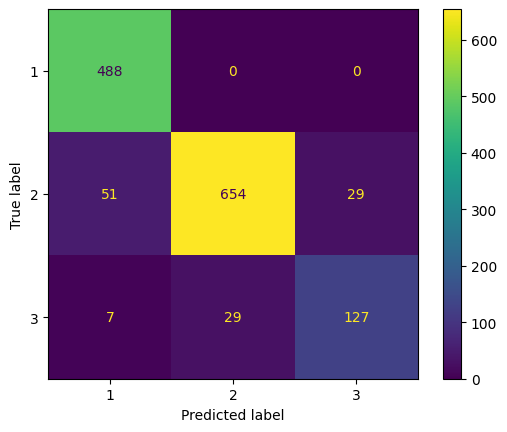

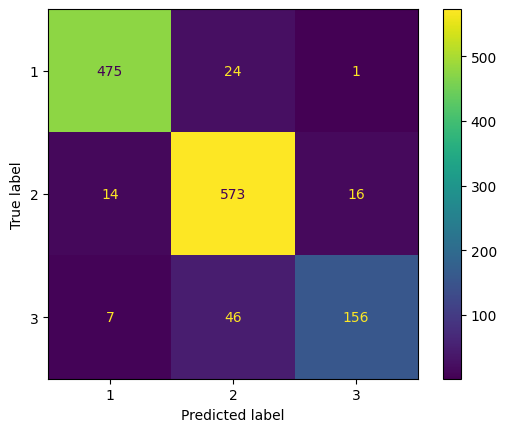

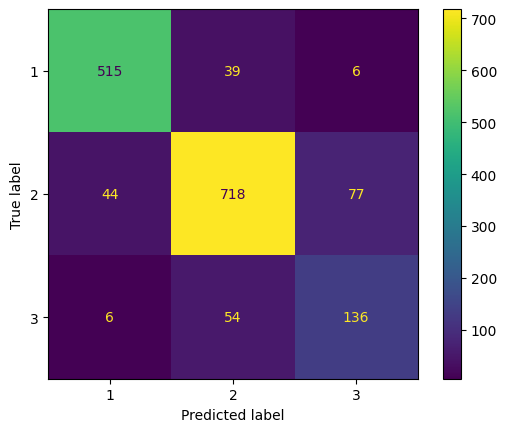

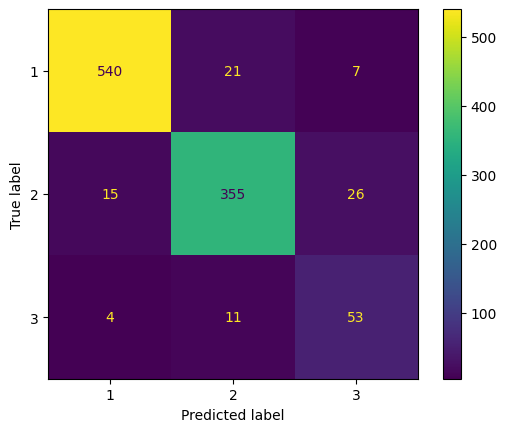

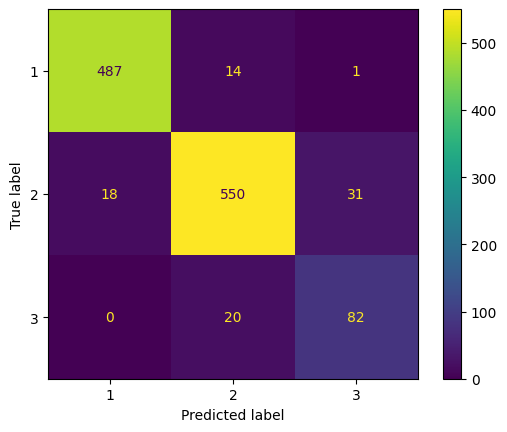

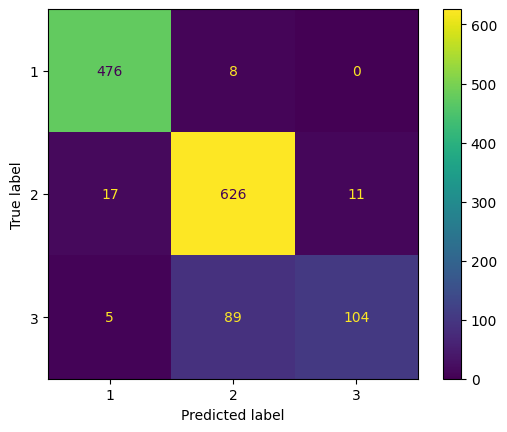

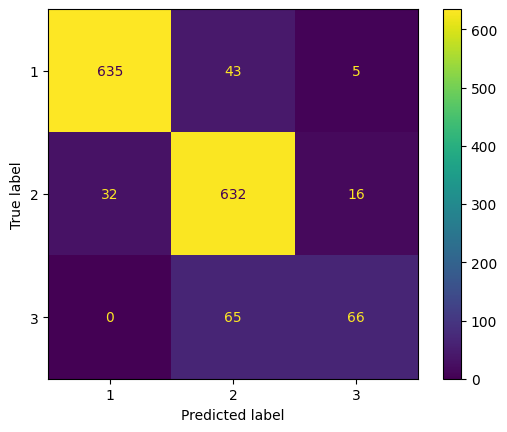

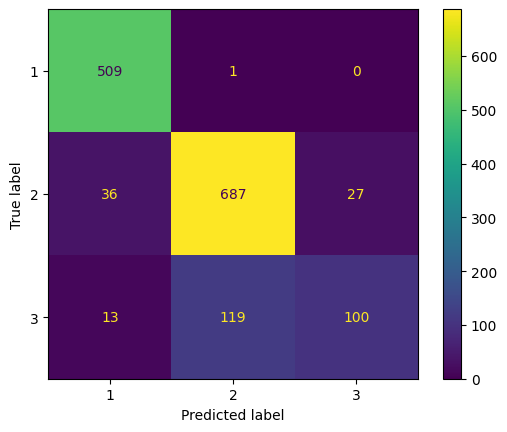

In [9]:
# Leave One Participant Out Cross Validation, using group_id == participant_id
logo = LeaveOneGroupOut()

group_id = 0
for train, test in logo.split(X, y, groups=groups):
  print(f"Testing on participant: #{group_id}")
  group_id = group_id + 1

  # Training of the classifier
  model = RandomForestClassifier(n_estimators=100, random_state=42)
  X_train = X[train]
  y_train = y[train]
  model.fit(X_train, y_train)

  # Testing using the current participant data left out
  X_test = X[test]
  y_test = y[test]
  y_pred = model.predict(X_test)

  acc = accuracy_score(y_test, y_pred)

  print(f"Accuracy score: {acc}")

  # Create a confusion matrix and a report on all the metrics
  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
  disp.plot() # will appear at the end of the output

  print(classification_report(y_test, y_pred, target_names=EVENT_ID.keys()))
  print(EVENT_ID)